# CharXiv EDA — Checkpoint 2

Exploratory data analysis for *predict **failure** (`y=1`=incorrect) for each of the 3 target models*
— `GPT-4o`, `Claude-3-5-Sonnet`, and `GPT-4o-Random` — with a **separate classifier per target**.
Features: the **baseline** = item metadata; the **engineered** features = the **12 DeLeAn demand dims**
(the only engineered features — aggregates and difficulty proxies were removed).

`GPT-4o-Random` is a random-answer control that fails about 90 percent of items. Watch how it differs
from the two real models: its outcome tracks the answer format (metadata), not the reasoning demand.

**TRAIN only** (800 items, one row per item; each row carries a failure label per target). The
200-item test set is sealed. There is **no temporal component**, so no time-series or lag analysis.
Plots saved to `results/eda/`.

## 1. Setup and data

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import src.features.preprocessing as P
from src.features.transformers import DEMAND_DIMS
%matplotlib inline

EDA = ROOT / "results" / "eda"; EDA.mkdir(parents=True, exist_ok=True)
TARGETS = P.TARGET_MODELS
YCOLS = P.TARGET_YCOLS
con = P.connect(); train_ids, test_ids = P.get_split(con)
df = P.make_design_matrix(con, train_ids)   # one row per item (800 rows)
con.close()

item_dims = df.set_index("item_id")[DEMAND_DIMS]
print("items:", len(df), "| targets:", TARGETS)
print("failure rate by target:")
display(df[YCOLS].mean().round(3).rename("failure_rate").to_frame())

items: 800 | targets: ['GPT-4o', 'Claude-3-5-Sonnet', 'GPT-4o-Random']
failure rate by target:


,failure_rate
y__GPT-4o,0.514
y__Claude-3-5-Sonnet,0.390
y__GPT-4o-Random,0.899


## 2. Univariate distributions\n\nThe 12 DeLeAn demand dims are ordinal 0–5 (sparse). Bars/box + a sparsity table.

Demand dims (overall mean 1.48). Note CL is near-constant; GS/KNf are sparse.


,mean,std,pct_zero,pct_ge3
VL,2.281,0.642,0.008,0.354
AS,2.645,0.540,0.000,0.654
MCr,1.644,0.684,0.016,0.100
MCu,0.670,0.644,0.416,0.010
MA,2.399,1.376,0.126,0.450
VO,1.170,0.376,0.000,0.000
AT,2.565,0.521,0.000,0.568
GS,0.810,1.173,0.611,0.071
QLl,1.004,0.620,0.164,0.026
KNf,1.168,0.906,0.221,0.079


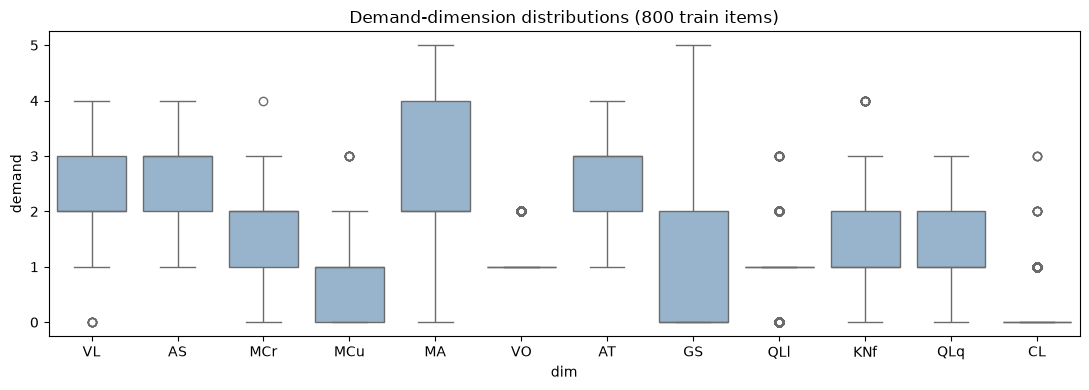

In [2]:
summary = pd.DataFrame({
    "mean": item_dims.mean(), "std": item_dims.std(),
    "pct_zero": (item_dims == 0).mean(), "pct_ge3": (item_dims >= 3).mean(),
}).loc[DEMAND_DIMS].round(3)
print("Demand dims (overall mean %.2f). Note CL is near-constant; GS/KNf are sparse." % item_dims.values.mean())
display(summary)

fig, ax = plt.subplots(figsize=(11, 4))
item_dims.melt(var_name="dim", value_name="demand").pipe(
    lambda d: sns.boxplot(data=d, x="dim", y="demand", order=DEMAND_DIMS, ax=ax, color="#8fb4d6"))
ax.set_title("Demand-dimension distributions (800 train items)")
fig.tight_layout(); fig.savefig(EDA / "demand_distributions.png", dpi=130); plt.show()

## 3. Missingness\n\nAll three targets have **0 dropped** reasoning rows, so the design matrix is complete.

In [3]:
cols = DEMAND_DIMS + P.CATEGORICAL + YCOLS
miss = df[cols].isna().sum()
print("total missing values:", int(miss.sum()))
display(miss.to_frame("n_missing").T)

total missing values: 0


,VL,AS,MCr,MCu,MA,VO,AT,GS,QLl,KNf,QLq,CL,category,inst_category,year,y__GPT-4o,y__Claude-3-5-Sonnet,y__GPT-4o-Random
n_missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 4. Relationships\n\nInter-dim correlation, and how the features relate to **target failure** for each model.

|Spearman| >= 0.40 pairs: [('VL', 'AS', np.float64(0.42)), ('VL', 'MA', np.float64(0.42)), ('AS', 'MCr', np.float64(0.47)), ('MCr', 'MCu', np.float64(0.41)), ('MCr', 'QLl', np.float64(0.41)), ('QLl', 'QLq', np.float64(0.46))]


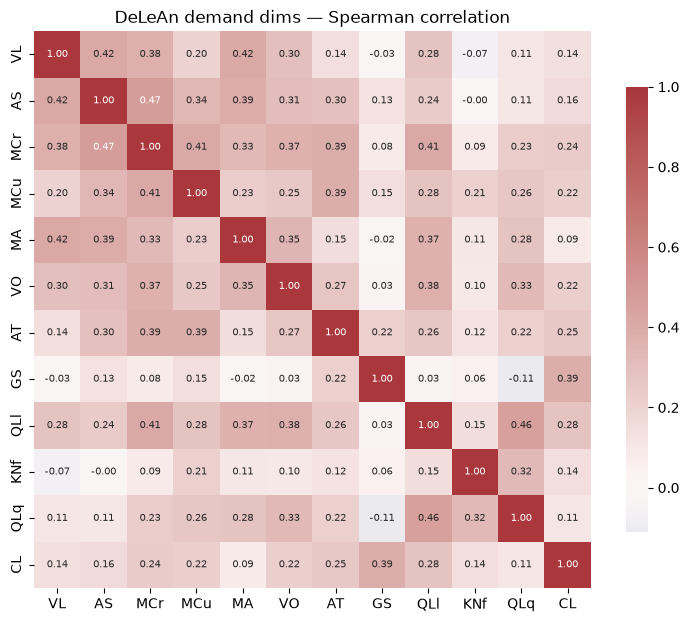

In [4]:
# 4a. Spearman correlation among the 12 demand dims (ordinal -> Spearman)
corr = item_dims.corr(method="spearman")
hi = [(a, b, round(corr.loc[a, b], 2)) for i, a in enumerate(DEMAND_DIMS) for b in DEMAND_DIMS[i+1:]
      if abs(corr.loc[a, b]) >= 0.4]
print("|Spearman| >= 0.40 pairs:", hi or "none (dims largely independent)")
fig, ax = plt.subplots(figsize=(7.5, 6.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True,
            cbar_kws={"shrink": .8}, annot_kws={"size": 7}, ax=ax)
ax.set_title("DeLeAn demand dims — Spearman correlation")
fig.tight_layout(); fig.savefig(EDA / "demand_correlation.png", dpi=130); plt.show()

Positive = failed items demand MORE on that dim. Real models rise on most dims; the random
control barely moves, because reasoning demand does not drive a random answer.


,GPT-4o,Claude-3-5-Sonnet,GPT-4o-Random
VL,0.182,0.190,0.148
AS,0.230,0.214,0.058
MCr,0.267,0.237,0.167
MCu,0.313,0.236,0.004
MA,0.286,0.387,0.114
VO,0.116,0.089,0.066
AT,0.164,0.104,-0.017
GS,-0.095,-0.035,-0.417
QLl,0.067,0.115,0.018
KNf,0.041,0.035,-0.102


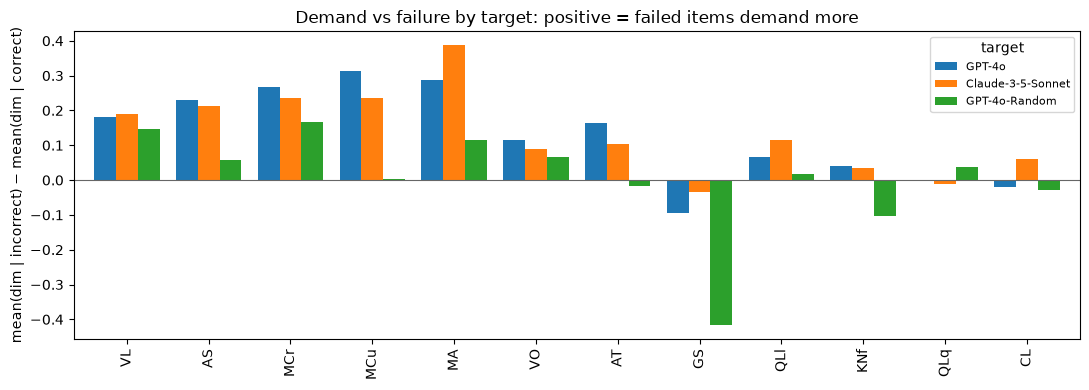

In [5]:
# 4b. Demand dims vs failure, per target: mean(dim | incorrect) - mean(dim | correct)
delta = pd.DataFrame({t: (df.groupby(P.ycol(t))[DEMAND_DIMS].mean().loc[1]
                          - df.groupby(P.ycol(t))[DEMAND_DIMS].mean().loc[0])
                      for t in TARGETS}).loc[DEMAND_DIMS].round(3)
print("Positive = failed items demand MORE on that dim. Real models rise on most dims; the random")
print("control barely moves, because reasoning demand does not drive a random answer.")
display(delta)
fig, ax = plt.subplots(figsize=(11, 4))
delta.plot.bar(ax=ax, width=0.8)
ax.axhline(0, c="0.4", lw=.8); ax.set_ylabel("mean(dim | incorrect) − mean(dim | correct)")
ax.set_title("Demand vs failure by target: positive = failed items demand more")
ax.legend(title="target", fontsize=8)
fig.tight_layout(); fig.savefig(EDA / "demand_vs_failure.png", dpi=130); plt.show()

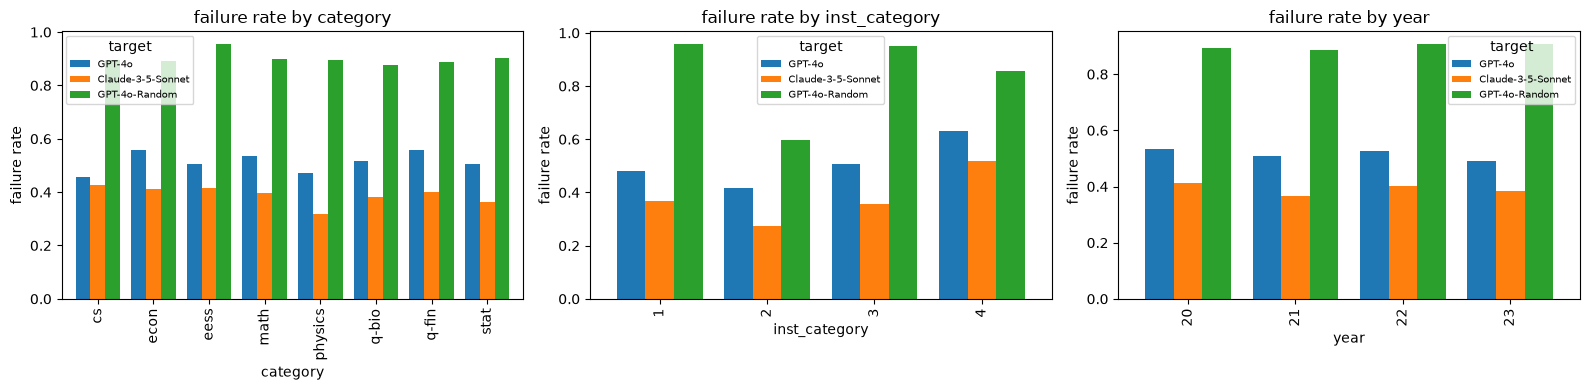

Metadata varies only mildly with failure for the two real models (candidate to drop in nb13),
but strongly for GPT-4o-Random on inst_category, an answer-type proxy that governs random luck.


,GPT-4o,Claude-3-5-Sonnet,GPT-4o-Random
inst_category,,,
1,0.480,0.368,0.958
2,0.416,0.273,0.597
3,0.505,0.355,0.952
4,0.630,0.519,0.856


In [6]:
# 4c. Failure rate by item metadata (category / inst_category / year), per target
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, P.CATEGORICAL):
    tab = df.groupby(col)[YCOLS].mean()
    tab.columns = TARGETS
    tab.plot.bar(ax=ax, width=0.8)
    ax.set_title(f"failure rate by {col}"); ax.set_ylabel("failure rate")
    ax.legend(title="target", fontsize=7)
fig.tight_layout(); fig.savefig(EDA / "failure_by_metadata.png", dpi=130); plt.show()
print("Metadata varies only mildly with failure for the two real models (candidate to drop in nb13),")
print("but strongly for GPT-4o-Random on inst_category, an answer-type proxy that governs random luck.")
display(df.groupby("inst_category")[YCOLS].mean().round(3).set_axis(TARGETS, axis=1))

## 5. Outlier detection\n\n`IsolationForest` + max |z| on the 12-dim demand profiles (item level). Atypical items are flagged, not removed — they are legitimate hard/unusual charts.

IsolationForest flags 24 / 800 items (~3%) as atypical-demand. Keep them.


,VL,AS,MCr,MCu,MA,VO,AT,GS,QLl,KNf,QLq,CL,max_abs_z
item_id,,,,,,,,,,,,,
charxiv_val_1081,0.0,1.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0,2.0,1.0,0.0,3.55
charxiv_val_1108,2.0,3.0,2.0,2.0,3.0,2.0,3.0,2.0,1.0,3.0,3.0,2.0,4.05
charxiv_val_1222,1.0,2.0,2.0,1.0,0.0,1.0,3.0,4.0,2.0,3.0,2.0,1.0,2.72
charxiv_val_1329,2.0,2.0,1.0,2.0,0.0,1.0,3.0,3.0,1.0,4.0,2.0,1.0,3.13
charxiv_val_1373,0.0,1.0,0.0,0.0,0.0,1.0,2.0,3.0,1.0,3.0,1.0,1.0,3.55
charxiv_val_1375,3.0,4.0,3.0,2.0,4.0,2.0,3.0,2.0,3.0,1.0,1.0,0.0,3.22
charxiv_val_1609,3.0,2.0,3.0,2.0,1.0,2.0,3.0,0.0,2.0,3.0,3.0,1.0,3.07
charxiv_val_1965,2.0,3.0,2.0,3.0,1.0,2.0,3.0,0.0,2.0,3.0,3.0,0.0,3.62


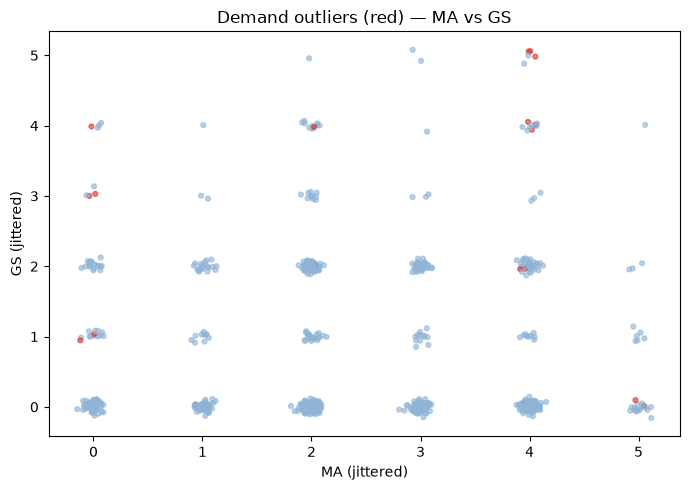

In [7]:
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore
z = np.abs(zscore(item_dims, axis=0))
iso = IsolationForest(contamination=0.03, random_state=0).fit(item_dims)
flag = iso.predict(item_dims) == -1
out = item_dims.loc[flag].assign(max_abs_z=z[flag].max(axis=1).round(2))
print(f"IsolationForest flags {flag.sum()} / {len(item_dims)} items (~3%) as atypical-demand. Keep them.")
display(out.head(8))
fig, ax = plt.subplots(figsize=(7, 5))
rng = np.random.default_rng(0)
ax.scatter(item_dims["MA"] + rng.normal(0, .05, len(item_dims)),
           item_dims["GS"] + rng.normal(0, .05, len(item_dims)),
           c=np.where(flag, "#de2d26", "#8fb4d6"), s=12, alpha=.6)
ax.set(xlabel="MA (jittered)", ylabel="GS (jittered)", title="Demand outliers (red) — MA vs GS")
fig.tight_layout(); fig.savefig(EDA / "demand_outliers.png", dpi=130); plt.show()

## 6. Audit summary

- **Distributions:** the 12 dims are sparse ordinals (overall mean ≈ 1.5); `CL` is near-constant
  (~82% zeros) and `GS`/`KNf` are sparse — flagged for the feature-selection funnel (nb13).
- **Missingness:** none — all three targets have complete reasoning rows.
- **Relationships:** demand dims are largely independent (few |Spearman| ≥ 0.4). For the two real
  models, failed items demand *more* on most dims (`GS` is the exception), so the demand dims carry
  a genuine reasoning-difficulty signal. For `GPT-4o-Random` the demand deltas are near zero, while
  its failure tracks `inst_category` (an answer-type proxy) — a random guess's luck depends on the
  answer format, not the reasoning demand. Metadata varies only mildly with real-model failure
  (candidate to drop).
- **Outliers:** ~3% atypical-demand items — kept (legitimate hard charts).

Next (nb13): the selection funnel on the 12 dims; (nb14) does adding the DeLeAn dims lift ROC-AUC over
the metadata baseline for the real models?